# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
df = pd.read_csv("cleaned_aviation_data.csv")

df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total_Passengers_Est,Fatal_Injury_Rate,Serious_Injury_Rate,Severe_Injury_Rate,Is_Destroyed,Make_Model
0,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,IMC,Cruise,Probable Cause,02-05-2011,2.0,0.500000,0.500000,1.000000,True,PIPER_PA-28-140
1,20001214X40407,Accident,MKC84FA197,1984-07-03,"WRIGHT, AR",United States,NaN,NaN,NaN,NaN,...,VMC,Maneuvering,Probable Cause,15-12-2009,1.0,1.000000,0.000000,1.000000,True,PIPER_PA-18-150
2,20001214X41706,Accident,ATL85FA072,1984-12-30,"DUBLIN, VA",United States,NaN,NaN,PSK,NEW RIVER VALLEY,...,VMC,Maneuvering,Probable Cause,17-10-2016,1.0,1.000000,0.000000,1.000000,True,CESSNA_182A
3,20001214X35509,Accident,DEN85LA064,1985-01-14,"WAPITI, WY",United States,NaN,NaN,NaN,NaN,...,VMC,Maneuvering,Probable Cause,12-01-2016,2.0,0.000000,0.500000,0.500000,True,CESSNA_182Q
4,20001214X36887,Accident,NYC85FA145B,1985-06-11,"BELMAR, NJ",United States,NaN,NaN,BLM,BELMAR MONMOUTH CO.,...,VMC,Takeoff,Probable Cause,08-04-2013,6.0,0.166667,0.166667,0.333333,True,CESSNA_152


In [4]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date', 'Total_Passengers_Est', 'Fatal_Injury_Rate',
       'Serious_Injury_Rate', 'Severe_Injury_Rate', 'Is_Destroyed',
       'Make_Model'],
      dtype='str')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
#cleaning
df["Total_Passengers_Est"] = df["Total_Passengers_Est"].fillna(0)

df["Total_Passengers_Est"]

0       2.0
1       1.0
2       1.0
3       2.0
4       6.0
       ... 
6697    3.0
6698    2.0
6699    2.0
6700    1.0
6701    1.0
Name: Total_Passengers_Est, Length: 6702, dtype: float64

In [6]:
df["Total_Passengers_Est"]

0       2.0
1       1.0
2       1.0
3       2.0
4       6.0
       ... 
6697    3.0
6698    2.0
6699    2.0
6700    1.0
6701    1.0
Name: Total_Passengers_Est, Length: 6702, dtype: float64

In [7]:
#creating small vs large aircraft groups

df["aircraft_size"] = df["Total_Passengers_Est"].apply(
    lambda x: "small" if x <= 20 else "large"
)

df["aircraft_size"]


0       small
1       small
2       small
3       small
4       small
        ...  
6697    small
6698    small
6699    small
6700    small
6701    small
Name: aircraft_size, Length: 6702, dtype: str

In [8]:
#small aircraft sample filter

small_df = df[df["aircraft_size"] == "small"]

small_make_stats = small_df.groupby("Make").agg({
    "Total.Fatal.Injuries": "mean",
    "Total.Serious.Injuries": "mean",
    "Is_Destroyed": "mean"
}).sort_values("Total.Fatal.Injuries")

small_make_stats.head(10)

small_make_stats

,Total.Fatal.Injuries,Total.Serious.Injuries,Is_Destroyed
Make,,,
BOEING,0.000000,0.200000,0.066667
STINSON,0.075472,0.415094,0.000000
LUSCOMBE,0.081967,0.229508,0.000000
AERONCA,0.168539,0.247191,0.033708
CESSNA,0.281994,0.211310,0.074405
PIPER,0.286734,0.208804,0.083284
MOONEY,0.487179,0.262821,0.160256
CIRRUS,0.577778,0.366667,0.266667
CIRRUS DESIGN CORP,0.591549,0.239437,0.169014


In [9]:
#large aircraft sample filter

large_df = df[df["aircraft_size"] == "large"]

large_make_stats = large_df.groupby("Make").agg({
    "Total.Fatal.Injuries": "mean",
    "Total.Serious.Injuries": "mean",
    "Is_Destroyed": "mean"
}).sort_values("Total.Fatal.Injuries")

large_make_stats.head(10)

large_make_stats

,Total.Fatal.Injuries,Total.Serious.Injuries,Is_Destroyed
Make,,,
BOEING,13.545455,3.0,0.111111


In [10]:
#adding sample size filter

small_df = df[df["aircraft_size"] == "small"]

# Step 1: filter makes with at least 4 observations
valid_small_makes = small_df["Make"].value_counts()
valid_small_makes = valid_small_makes[valid_small_makes >= 4].index

small_df_filtered = small_df[small_df["Make"].isin(valid_small_makes)]

# Step 2: compute stats
small_make_stats = small_df_filtered.groupby("Make").agg({
    "Total.Fatal.Injuries": "mean",
    "Total.Serious.Injuries": "mean",
    "Is_Destroyed": "mean"
})

small_make_stats

,Total.Fatal.Injuries,Total.Serious.Injuries,Is_Destroyed
Make,,,
AERONCA,0.168539,0.247191,0.033708
BEECH,0.760563,0.221831,0.193662
BOEING,0.000000,0.200000,0.066667
CESSNA,0.281994,0.211310,0.074405
CIRRUS,0.577778,0.366667,0.266667
CIRRUS DESIGN CORP,0.591549,0.239437,0.169014
LUSCOMBE,0.081967,0.229508,0.000000
MOONEY,0.487179,0.262821,0.160256
PIPER,0.286734,0.208804,0.083284


### Observations (Small Aircraft)

- LUSCOMBE, STINSON, and AERONCA show the lowest fatal injury and destruction rates, making them the safest options.

- CESSNA and PIPER have moderate fatal injury rates but relatively low destruction rates, indicating acceptable safety performance.

- CIRRUS and BEECH exhibit higher fatal injury and destruction rates, suggesting a higher risk compared to other manufacturers.

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [11]:
#small aircraft

small_df = df[df["aircraft_size"] == "small"]

# Filter ≥4 observations
valid_small = small_df["Make"].value_counts()
valid_small = valid_small[valid_small >= 4].index

small_df = small_df[small_df["Make"].isin(valid_small)]

# Compute mean injury risk
small_make_risk = small_df.groupby("Make")["Is_Destroyed"].mean()

# Select 15 safest (lowest risk)
small_top15 = small_make_risk.sort_values().head(15)

small_top15

Make
LUSCOMBE              0.000000
STINSON               0.000000
AERONCA               0.033708
BOEING                0.066667
CESSNA                0.074405
PIPER                 0.083284
MOONEY                0.160256
CIRRUS DESIGN CORP    0.169014
BEECH                 0.193662
CIRRUS                0.266667
Name: Is_Destroyed, dtype: float64

In [12]:
#large aircraft

large_df = df[df["aircraft_size"] == "large"]

valid_large = large_df["Make"].value_counts()
valid_large = valid_large[valid_large >= 4].index

large_df = large_df[large_df["Make"].isin(valid_large)]

large_make_risk = large_df.groupby("Make")["Is_Destroyed"].mean()

large_top15 = large_make_risk.sort_values().head(15)

large_top15

Make
BOEING    0.111111
Name: Is_Destroyed, dtype: float64

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [14]:
#filter small aircraft and valid sample size

small_df = df[df["aircraft_size"] == "small"]

# Keep ≥4 observations
valid_small = small_df["Make"].value_counts()
valid_small = valid_small[valid_small >= 4].index

small_df = small_df[small_df["Make"].isin(valid_small)]

small_df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Broad.phase.of.flight,Report.Status,Publication.Date,Total_Passengers_Est,Fatal_Injury_Rate,Serious_Injury_Rate,Severe_Injury_Rate,Is_Destroyed,Make_Model,aircraft_size
0,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,Cruise,Probable Cause,02-05-2011,2.0,0.500000,0.500000,1.000000,True,PIPER_PA-28-140,small
1,20001214X40407,Accident,MKC84FA197,1984-07-03,"WRIGHT, AR",United States,NaN,NaN,NaN,NaN,...,Maneuvering,Probable Cause,15-12-2009,1.0,1.000000,0.000000,1.000000,True,PIPER_PA-18-150,small
2,20001214X41706,Accident,ATL85FA072,1984-12-30,"DUBLIN, VA",United States,NaN,NaN,PSK,NEW RIVER VALLEY,...,Maneuvering,Probable Cause,17-10-2016,1.0,1.000000,0.000000,1.000000,True,CESSNA_182A,small
3,20001214X35509,Accident,DEN85LA064,1985-01-14,"WAPITI, WY",United States,NaN,NaN,NaN,NaN,...,Maneuvering,Probable Cause,12-01-2016,2.0,0.000000,0.500000,0.500000,True,CESSNA_182Q,small
4,20001214X36887,Accident,NYC85FA145B,1985-06-11,"BELMAR, NJ",United States,NaN,NaN,BLM,BELMAR MONMOUTH CO.,...,Takeoff,Probable Cause,08-04-2013,6.0,0.166667,0.166667,0.333333,True,CESSNA_152,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6697,20221205106409,Accident,ERA23FA079,2022-12-03,"Venice, FL",United States,027347N,0082272W,KVNC,Venice Municipal Airport,...,Unknown,NaN,20-12-2022,3.0,1.000000,0.000000,1.000000,False,PIPER_PA28,small
6698,20221206106424,Accident,WPR23LA054,2022-12-04,"Fergus Falls, MN",United States,046936N,0096524W,FFM,Fergus Falls Municipal Airport,...,Unknown,NaN,13-12-2022,2.0,0.000000,0.000000,0.000000,False,CESSNA_A185F,small
6699,20221213106447,Accident,ERA23LA086,2022-12-08,"Covington, GA",United States,332754N,0835049W,NaN,NaN,...,Unknown,NaN,28-12-2022,2.0,0.000000,0.000000,0.000000,False,BEECH_A36,small
6700,20221212106444,Accident,ERA23LA085,2022-12-12,"Knoxville, TN",United States,355745N,0835218W,DKX,KNOXVILLE DOWNTOWN ISLAND,...,Unknown,NaN,15-12-2022,1.0,0.000000,0.000000,0.000000,False,CESSNA_172,small


In [15]:
#injury risk

small_df["injury_risk"] = small_df["Fatal_Injury_Rate"] + small_df["Serious_Injury_Rate"]

small_df["injury_risk"]

0       1.000000
1       1.000000
2       1.000000
3       0.500000
4       0.333333
          ...   
6697    1.000000
6698    0.000000
6699    0.000000
6700    0.000000
6701    0.000000
Name: injury_risk, Length: 6603, dtype: float64

In [16]:
#safest makes

safest_makes = (
    small_df.groupby("Make")["injury_risk"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

safest_makes

Index(['BOEING', 'LUSCOMBE', 'CESSNA', 'PIPER', 'STINSON', 'AERONCA', 'MOONEY',
       'BEECH', 'CIRRUS DESIGN CORP', 'CIRRUS'],
      dtype='str', name='Make')

In [17]:
#filter data set

plot_df = small_df[small_df["Make"].isin(safest_makes)]

plot_df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Report.Status,Publication.Date,Total_Passengers_Est,Fatal_Injury_Rate,Serious_Injury_Rate,Severe_Injury_Rate,Is_Destroyed,Make_Model,aircraft_size,injury_risk
0,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,Probable Cause,02-05-2011,2.0,0.500000,0.500000,1.000000,True,PIPER_PA-28-140,small,1.000000
1,20001214X40407,Accident,MKC84FA197,1984-07-03,"WRIGHT, AR",United States,NaN,NaN,NaN,NaN,...,Probable Cause,15-12-2009,1.0,1.000000,0.000000,1.000000,True,PIPER_PA-18-150,small,1.000000
2,20001214X41706,Accident,ATL85FA072,1984-12-30,"DUBLIN, VA",United States,NaN,NaN,PSK,NEW RIVER VALLEY,...,Probable Cause,17-10-2016,1.0,1.000000,0.000000,1.000000,True,CESSNA_182A,small,1.000000
3,20001214X35509,Accident,DEN85LA064,1985-01-14,"WAPITI, WY",United States,NaN,NaN,NaN,NaN,...,Probable Cause,12-01-2016,2.0,0.000000,0.500000,0.500000,True,CESSNA_182Q,small,0.500000
4,20001214X36887,Accident,NYC85FA145B,1985-06-11,"BELMAR, NJ",United States,NaN,NaN,BLM,BELMAR MONMOUTH CO.,...,Probable Cause,08-04-2013,6.0,0.166667,0.166667,0.333333,True,CESSNA_152,small,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6697,20221205106409,Accident,ERA23FA079,2022-12-03,"Venice, FL",United States,027347N,0082272W,KVNC,Venice Municipal Airport,...,NaN,20-12-2022,3.0,1.000000,0.000000,1.000000,False,PIPER_PA28,small,1.000000
6698,20221206106424,Accident,WPR23LA054,2022-12-04,"Fergus Falls, MN",United States,046936N,0096524W,FFM,Fergus Falls Municipal Airport,...,NaN,13-12-2022,2.0,0.000000,0.000000,0.000000,False,CESSNA_A185F,small,0.000000
6699,20221213106447,Accident,ERA23LA086,2022-12-08,"Covington, GA",United States,332754N,0835049W,NaN,NaN,...,NaN,28-12-2022,2.0,0.000000,0.000000,0.000000,False,BEECH_A36,small,0.000000
6700,20221212106444,Accident,ERA23LA085,2022-12-12,"Knoxville, TN",United States,355745N,0835218W,DKX,KNOXVILLE DOWNTOWN ISLAND,...,NaN,15-12-2022,1.0,0.000000,0.000000,0.000000,False,CESSNA_172,small,0.000000


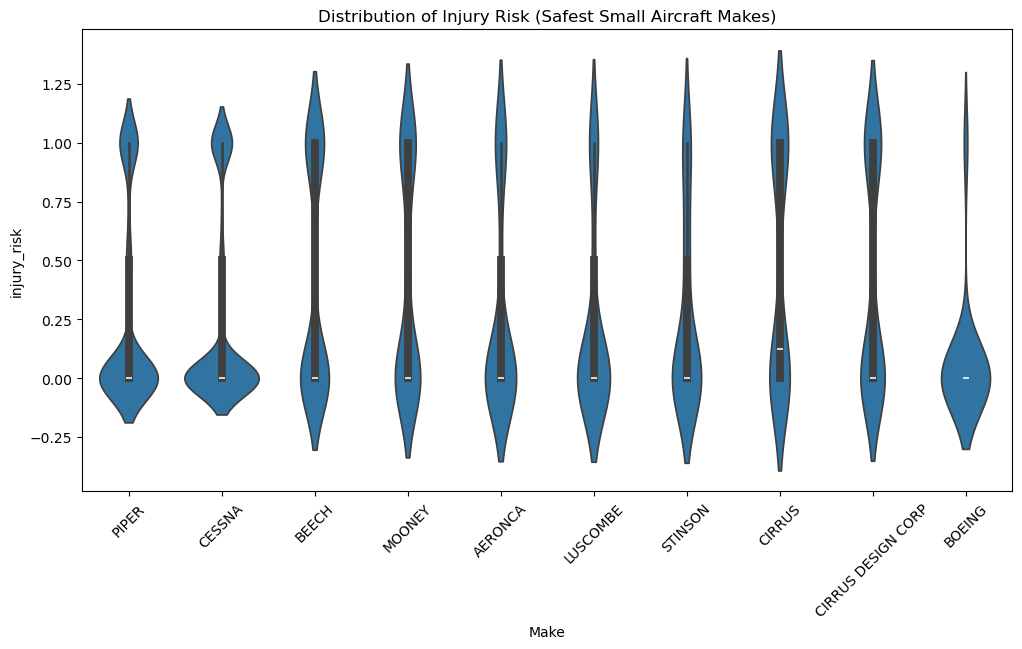

In [18]:
#violin plot

plt.figure(figsize=(12,6))

sns.violinplot(
    data=plot_df,
    x="Make",
    y="injury_risk"
)

plt.title("Distribution of Injury Risk (Safest Small Aircraft Makes)")
plt.xticks(rotation=45)
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [19]:
#filter large aircraft and sample size

large_df = df[df["aircraft_size"] == "large"]

# Keep ≥4 observations
valid_large = large_df["Make"].value_counts()
valid_large = valid_large[valid_large >= 4].index

large_df = large_df[large_df["Make"].isin(valid_large)]

large_df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Broad.phase.of.flight,Report.Status,Publication.Date,Total_Passengers_Est,Fatal_Injury_Rate,Serious_Injury_Rate,Severe_Injury_Rate,Is_Destroyed,Make_Model,aircraft_size
124,20031105X01861,Accident,NYC04CA003,2003-10-04,"BOSTON, MA",United States,42.364167,-71.005,BOS,Boston,...,Standing,Probable Cause,05-02-2004,76.0,0.000000,0.000000,0.0,False,BOEING_737,large
1349,20081003X16307,Accident,DCA08WA092,2008-08-24,"Bishkek, Kyrgyzstan",Kyrgyzstan,043425N,0742147E,FRU,Manas Airport,...,Unknown,;kh,03-11-2020,90.0,0.722222,0.277778,1.0,True,BOEING_737,large
1395,20081219X65313,Incident,ENG08IA042,2008-10-01,"Chicago, IL",United States,415321N,0873713W,MDW,Chicago Midway,...,Unknown,The right nose landing gear axle's failure fro...,03-11-2020,133.0,0.000000,0.000000,0.0,False,BOEING_737,large
1416,20081105X55127,Accident,DCA09WA008,2008-10-16,"Maiquetia, Venezuela",Venezuela,NaN,NaN,SVMI,"Maiquetia, Simon Bolivar",...,Unknown,.,03-11-2020,55.0,0.000000,0.000000,0.0,False,BOEING_737,large
1418,20100304X92243,Incident,ENG08WA050,2008-10-18,"Belgrade, Serbia, Suriname",Suriname,NaN,NaN,LYBE,"Nicola Tesla, Belgrade, Serbia",...,Unknown,NaN,03-11-2020,189.0,0.000000,0.000000,0.0,False,BOEING_737,large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6393,20220310104758,Incident,DCA22WA095,2022-03-09,"Manchester, OF",United Kingdom,NaN,NaN,NaN,NaN,...,Unknown,NaN,11-03-2022,177.0,0.000000,0.000000,0.0,False,BOEING_737,large
6408,20220321104807,Accident,DCA22WA102,2022-03-21,"Wuzhou,",China,NaN,NaN,NaN,NaN,...,Unknown,NaN,23-05-2022,132.0,1.000000,0.000000,1.0,True,BOEING_737,large
6456,20220511105061,Accident,DCA22WA122,2022-05-06,"Naples,",Italy,NaN,NaN,LIRN,Naples International Airport,...,Unknown,NaN,20-05-2022,154.0,0.000000,0.000000,0.0,False,BOEING_737,large
6457,20220515105077,Incident,DCA22WA123,2022-05-06,"Kathmandu,",Nepal,NaN,NaN,NaN,NaN,...,Unknown,NaN,20-05-2022,173.0,0.000000,0.000000,0.0,False,BOEING_737,large


In [20]:
#injury risk

large_df["injury_risk"] = large_df["Fatal_Injury_Rate"] + large_df["Serious_Injury_Rate"]

large_df["injury_risk"]



124     0.0
1349    1.0
1395    0.0
1416    0.0
1418    0.0
       ... 
6393    0.0
6408    1.0
6456    0.0
6457    0.0
6621    0.0
Name: injury_risk, Length: 99, dtype: float64

In [22]:
#safest makes

safest_large = (
    large_df.groupby("Make")["injury_risk"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

safest_large

Index(['BOEING'], dtype='str', name='Make')

In [23]:
#filter for plot

plot_large_df = large_df[large_df["Make"].isin(safest_large)]

plot_large_df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Report.Status,Publication.Date,Total_Passengers_Est,Fatal_Injury_Rate,Serious_Injury_Rate,Severe_Injury_Rate,Is_Destroyed,Make_Model,aircraft_size,injury_risk
124,20031105X01861,Accident,NYC04CA003,2003-10-04,"BOSTON, MA",United States,42.364167,-71.005,BOS,Boston,...,Probable Cause,05-02-2004,76.0,0.000000,0.000000,0.0,False,BOEING_737,large,0.0
1349,20081003X16307,Accident,DCA08WA092,2008-08-24,"Bishkek, Kyrgyzstan",Kyrgyzstan,043425N,0742147E,FRU,Manas Airport,...,;kh,03-11-2020,90.0,0.722222,0.277778,1.0,True,BOEING_737,large,1.0
1395,20081219X65313,Incident,ENG08IA042,2008-10-01,"Chicago, IL",United States,415321N,0873713W,MDW,Chicago Midway,...,The right nose landing gear axle's failure fro...,03-11-2020,133.0,0.000000,0.000000,0.0,False,BOEING_737,large,0.0
1416,20081105X55127,Accident,DCA09WA008,2008-10-16,"Maiquetia, Venezuela",Venezuela,NaN,NaN,SVMI,"Maiquetia, Simon Bolivar",...,.,03-11-2020,55.0,0.000000,0.000000,0.0,False,BOEING_737,large,0.0
1418,20100304X92243,Incident,ENG08WA050,2008-10-18,"Belgrade, Serbia, Suriname",Suriname,NaN,NaN,LYBE,"Nicola Tesla, Belgrade, Serbia",...,NaN,03-11-2020,189.0,0.000000,0.000000,0.0,False,BOEING_737,large,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6393,20220310104758,Incident,DCA22WA095,2022-03-09,"Manchester, OF",United Kingdom,NaN,NaN,NaN,NaN,...,NaN,11-03-2022,177.0,0.000000,0.000000,0.0,False,BOEING_737,large,0.0
6408,20220321104807,Accident,DCA22WA102,2022-03-21,"Wuzhou,",China,NaN,NaN,NaN,NaN,...,NaN,23-05-2022,132.0,1.000000,0.000000,1.0,True,BOEING_737,large,1.0
6456,20220511105061,Accident,DCA22WA122,2022-05-06,"Naples,",Italy,NaN,NaN,LIRN,Naples International Airport,...,NaN,20-05-2022,154.0,0.000000,0.000000,0.0,False,BOEING_737,large,0.0
6457,20220515105077,Incident,DCA22WA123,2022-05-06,"Kathmandu,",Nepal,NaN,NaN,NaN,NaN,...,NaN,20-05-2022,173.0,0.000000,0.000000,0.0,False,BOEING_737,large,0.0


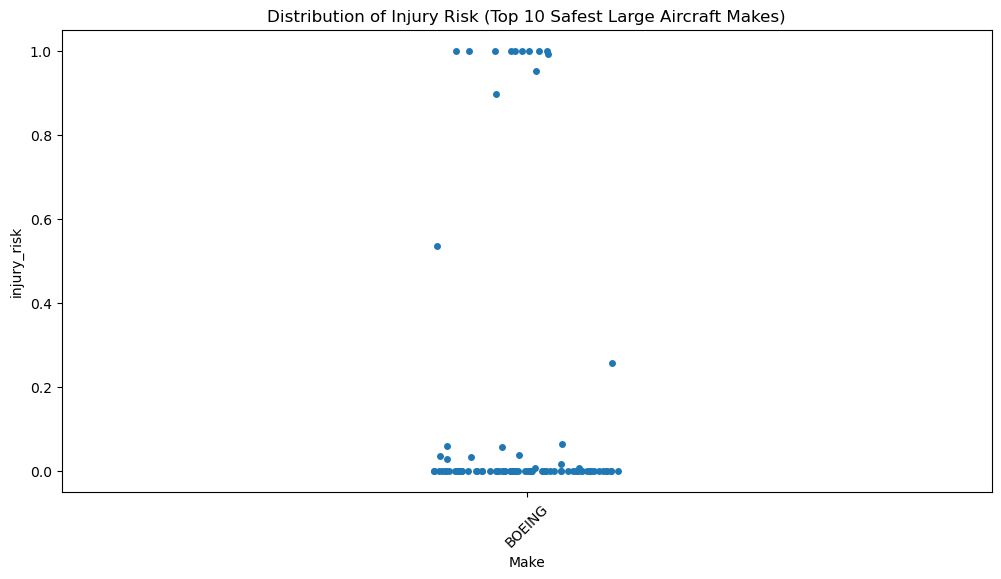

In [24]:
#strip plot

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)

plt.figure(figsize=(12,6))

sns.stripplot(
    data=plot_large_df,
    x="Make",
    y="injury_risk",
    jitter=True
)

plt.title("Distribution of Injury Risk (Top 10 Safest Large Aircraft Makes)")
plt.xticks(rotation=45)
plt.show()


**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [25]:
#small aircraft

small_df = df[df["aircraft_size"] == "small"]

# Filter ≥4 observations
valid_small = small_df["Make"].value_counts()
valid_small = valid_small[valid_small >= 4].index

small_df = small_df[small_df["Make"].isin(valid_small)]

# Compute destruction rate
small_destroy = small_df.groupby("Make")["Is_Destroyed"].mean()

# Get 15 lowest
small_air_destroy = small_destroy.sort_values().head(15)

small_air_destroy

Make
LUSCOMBE              0.000000
STINSON               0.000000
AERONCA               0.033708
BOEING                0.066667
CESSNA                0.074405
PIPER                 0.083284
MOONEY                0.160256
CIRRUS DESIGN CORP    0.169014
BEECH                 0.193662
CIRRUS                0.266667
Name: Is_Destroyed, dtype: float64

In [26]:
#large aircraft

large_df = df[df["aircraft_size"] == "large"]

valid_large = large_df["Make"].value_counts()
valid_large = valid_large[valid_large >= 4].index

large_df = large_df[large_df["Make"].isin(valid_large)]

large_destroy = large_df.groupby("Make")["Is_Destroyed"].mean()

large_air_destroy = large_destroy.sort_values().head(15)

large_air_destroy

Make
BOEING    0.111111
Name: Is_Destroyed, dtype: float64

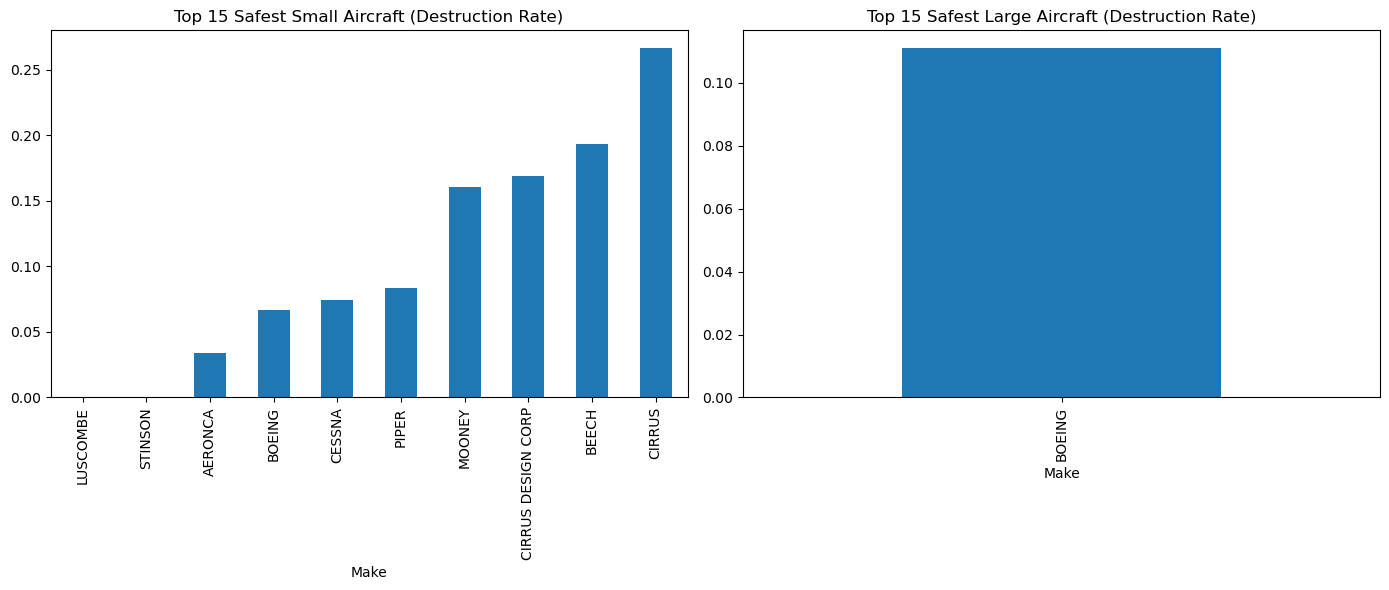

In [27]:
#plot


plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
small_air_destroy.plot(kind="bar")
plt.title("Top 15 Safest Small Aircraft (Destruction Rate)")

plt.subplot(1,2,2)
large_air_destroy.plot(kind="bar")
plt.title("Top 15 Safest Large Aircraft (Destruction Rate)")

plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Discussions on my findings

- Safer manufacturers such as LUSCOMBE, STINSON, and AERONCA consistently show low destruction rates and low fatal/serious injury fractions, making them strong recommendations for small aircraft. CESSNA and PIPER also demonstrate moderate but acceptable safety performance across both metrics.

- In contrast, manufacturers like CIRRUS and BEECH exhibit higher injury and destruction rates, indicating a comparatively higher risk profile and making them less favorable choices.

- The visualizations show that small aircraft have greater variability in injury risk, with some manufacturers displaying wide distributions (indicating inconsistent outcomes). On the other hand, large aircraft tend to have more tightly clustered and lower injury rates, suggesting more consistent safety performance, although occasional outliers still exist.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [28]:
#filter dataset

large_df = df[df["aircraft_size"] == "large"]

large_df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Broad.phase.of.flight,Report.Status,Publication.Date,Total_Passengers_Est,Fatal_Injury_Rate,Serious_Injury_Rate,Severe_Injury_Rate,Is_Destroyed,Make_Model,aircraft_size
124,20031105X01861,Accident,NYC04CA003,2003-10-04,"BOSTON, MA",United States,42.364167,-71.005,BOS,Boston,...,Standing,Probable Cause,05-02-2004,76.0,0.000000,0.000000,0.0,False,BOEING_737,large
1349,20081003X16307,Accident,DCA08WA092,2008-08-24,"Bishkek, Kyrgyzstan",Kyrgyzstan,043425N,0742147E,FRU,Manas Airport,...,Unknown,;kh,03-11-2020,90.0,0.722222,0.277778,1.0,True,BOEING_737,large
1395,20081219X65313,Incident,ENG08IA042,2008-10-01,"Chicago, IL",United States,415321N,0873713W,MDW,Chicago Midway,...,Unknown,The right nose landing gear axle's failure fro...,03-11-2020,133.0,0.000000,0.000000,0.0,False,BOEING_737,large
1416,20081105X55127,Accident,DCA09WA008,2008-10-16,"Maiquetia, Venezuela",Venezuela,NaN,NaN,SVMI,"Maiquetia, Simon Bolivar",...,Unknown,.,03-11-2020,55.0,0.000000,0.000000,0.0,False,BOEING_737,large
1418,20100304X92243,Incident,ENG08WA050,2008-10-18,"Belgrade, Serbia, Suriname",Suriname,NaN,NaN,LYBE,"Nicola Tesla, Belgrade, Serbia",...,Unknown,NaN,03-11-2020,189.0,0.000000,0.000000,0.0,False,BOEING_737,large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6393,20220310104758,Incident,DCA22WA095,2022-03-09,"Manchester, OF",United Kingdom,NaN,NaN,NaN,NaN,...,Unknown,NaN,11-03-2022,177.0,0.000000,0.000000,0.0,False,BOEING_737,large
6408,20220321104807,Accident,DCA22WA102,2022-03-21,"Wuzhou,",China,NaN,NaN,NaN,NaN,...,Unknown,NaN,23-05-2022,132.0,1.000000,0.000000,1.0,True,BOEING_737,large
6456,20220511105061,Accident,DCA22WA122,2022-05-06,"Naples,",Italy,NaN,NaN,LIRN,Naples International Airport,...,Unknown,NaN,20-05-2022,154.0,0.000000,0.000000,0.0,False,BOEING_737,large
6457,20220515105077,Incident,DCA22WA123,2022-05-06,"Kathmandu,",Nepal,NaN,NaN,NaN,NaN,...,Unknown,NaN,20-05-2022,173.0,0.000000,0.000000,0.0,False,BOEING_737,large


In [29]:
# Count how many times each aircraft Make appears in the large aircraft dataset
valid_large = large_df["Make"].value_counts()

# Keep only Makes that have at least 10 observations (ensures statistical reliability)
valid_large = valid_large[valid_large >= 10].index

# Filter the dataset to include only those Makes with 10 or more records
large_df = large_df[large_df["Make"].isin(valid_large)]
large_df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Broad.phase.of.flight,Report.Status,Publication.Date,Total_Passengers_Est,Fatal_Injury_Rate,Serious_Injury_Rate,Severe_Injury_Rate,Is_Destroyed,Make_Model,aircraft_size
124,20031105X01861,Accident,NYC04CA003,2003-10-04,"BOSTON, MA",United States,42.364167,-71.005,BOS,Boston,...,Standing,Probable Cause,05-02-2004,76.0,0.000000,0.000000,0.0,False,BOEING_737,large
1349,20081003X16307,Accident,DCA08WA092,2008-08-24,"Bishkek, Kyrgyzstan",Kyrgyzstan,043425N,0742147E,FRU,Manas Airport,...,Unknown,;kh,03-11-2020,90.0,0.722222,0.277778,1.0,True,BOEING_737,large
1395,20081219X65313,Incident,ENG08IA042,2008-10-01,"Chicago, IL",United States,415321N,0873713W,MDW,Chicago Midway,...,Unknown,The right nose landing gear axle's failure fro...,03-11-2020,133.0,0.000000,0.000000,0.0,False,BOEING_737,large
1416,20081105X55127,Accident,DCA09WA008,2008-10-16,"Maiquetia, Venezuela",Venezuela,NaN,NaN,SVMI,"Maiquetia, Simon Bolivar",...,Unknown,.,03-11-2020,55.0,0.000000,0.000000,0.0,False,BOEING_737,large
1418,20100304X92243,Incident,ENG08WA050,2008-10-18,"Belgrade, Serbia, Suriname",Suriname,NaN,NaN,LYBE,"Nicola Tesla, Belgrade, Serbia",...,Unknown,NaN,03-11-2020,189.0,0.000000,0.000000,0.0,False,BOEING_737,large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6393,20220310104758,Incident,DCA22WA095,2022-03-09,"Manchester, OF",United Kingdom,NaN,NaN,NaN,NaN,...,Unknown,NaN,11-03-2022,177.0,0.000000,0.000000,0.0,False,BOEING_737,large
6408,20220321104807,Accident,DCA22WA102,2022-03-21,"Wuzhou,",China,NaN,NaN,NaN,NaN,...,Unknown,NaN,23-05-2022,132.0,1.000000,0.000000,1.0,True,BOEING_737,large
6456,20220511105061,Accident,DCA22WA122,2022-05-06,"Naples,",Italy,NaN,NaN,LIRN,Naples International Airport,...,Unknown,NaN,20-05-2022,154.0,0.000000,0.000000,0.0,False,BOEING_737,large
6457,20220515105077,Incident,DCA22WA123,2022-05-06,"Kathmandu,",Nepal,NaN,NaN,NaN,NaN,...,Unknown,NaN,20-05-2022,173.0,0.000000,0.000000,0.0,False,BOEING_737,large


In [30]:
#injury risk large aircraft

large_df["injury_risk"] = large_df["Fatal_Injury_Rate"] + large_df["Serious_Injury_Rate"]

large_df["injury_risk"]

124     0.0
1349    1.0
1395    0.0
1416    0.0
1418    0.0
       ... 
6393    0.0
6408    1.0
6456    0.0
6457    0.0
6621    0.0
Name: injury_risk, Length: 99, dtype: float64

In [31]:
#mean injury risk
large_mean_risk = large_df.groupby("Make")["injury_risk"].mean().sort_values()
large_mean_risk

Make
BOEING    0.130989
Name: injury_risk, dtype: float64

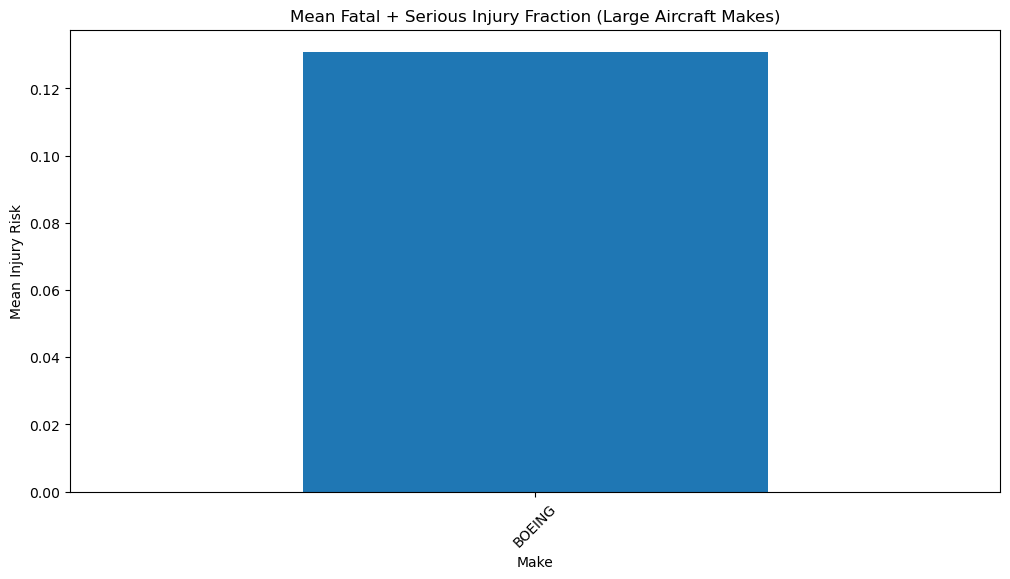

In [32]:
#plotting mean injury risk
plt.figure(figsize=(12,6))
large_mean_risk.plot(kind="bar")

plt.title("Mean Fatal + Serious Injury Fraction (Large Aircraft Makes)")
plt.ylabel("Mean Injury Risk")
plt.xticks(rotation=45)
plt.show()

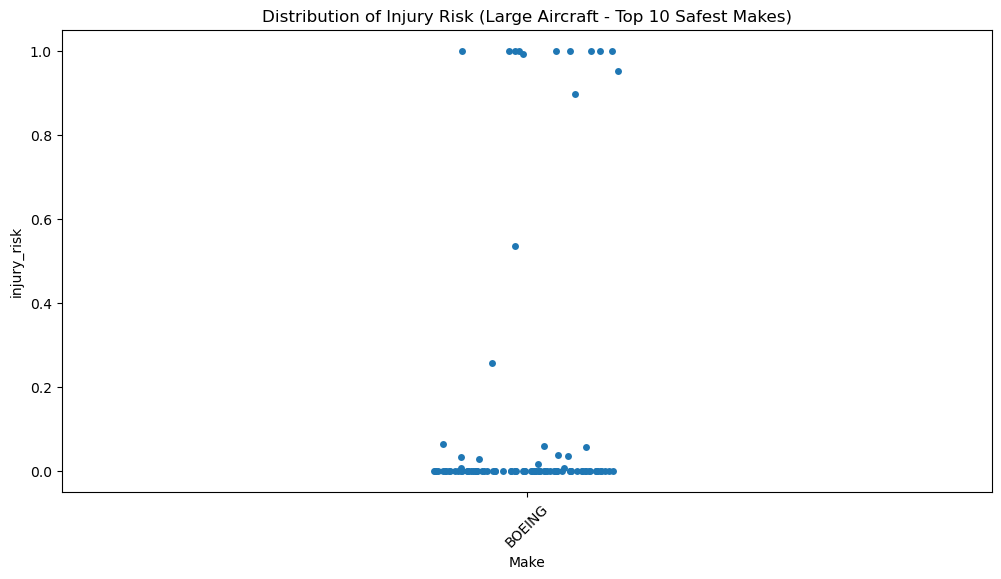

In [33]:
# distribution plot
# Keep top 10 safest makes for clarity
top10_large = large_mean_risk.head(10).index
plot_large = large_df[large_df["Make"].isin(top10_large)]

plt.figure(figsize=(12,6))

sns.stripplot(
    data=plot_large,
    x="Make",
    y="injury_risk",
    jitter=True
)

plt.title("Distribution of Injury Risk (Large Aircraft - Top 10 Safest Makes)")
plt.xticks(rotation=45)
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [34]:
#filter small aircraft

small_df = df[df["aircraft_size"] == "small"]
small_df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Broad.phase.of.flight,Report.Status,Publication.Date,Total_Passengers_Est,Fatal_Injury_Rate,Serious_Injury_Rate,Severe_Injury_Rate,Is_Destroyed,Make_Model,aircraft_size
0,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,Cruise,Probable Cause,02-05-2011,2.0,0.500000,0.500000,1.000000,True,PIPER_PA-28-140,small
1,20001214X40407,Accident,MKC84FA197,1984-07-03,"WRIGHT, AR",United States,NaN,NaN,NaN,NaN,...,Maneuvering,Probable Cause,15-12-2009,1.0,1.000000,0.000000,1.000000,True,PIPER_PA-18-150,small
2,20001214X41706,Accident,ATL85FA072,1984-12-30,"DUBLIN, VA",United States,NaN,NaN,PSK,NEW RIVER VALLEY,...,Maneuvering,Probable Cause,17-10-2016,1.0,1.000000,0.000000,1.000000,True,CESSNA_182A,small
3,20001214X35509,Accident,DEN85LA064,1985-01-14,"WAPITI, WY",United States,NaN,NaN,NaN,NaN,...,Maneuvering,Probable Cause,12-01-2016,2.0,0.000000,0.500000,0.500000,True,CESSNA_182Q,small
4,20001214X36887,Accident,NYC85FA145B,1985-06-11,"BELMAR, NJ",United States,NaN,NaN,BLM,BELMAR MONMOUTH CO.,...,Takeoff,Probable Cause,08-04-2013,6.0,0.166667,0.166667,0.333333,True,CESSNA_152,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6697,20221205106409,Accident,ERA23FA079,2022-12-03,"Venice, FL",United States,027347N,0082272W,KVNC,Venice Municipal Airport,...,Unknown,NaN,20-12-2022,3.0,1.000000,0.000000,1.000000,False,PIPER_PA28,small
6698,20221206106424,Accident,WPR23LA054,2022-12-04,"Fergus Falls, MN",United States,046936N,0096524W,FFM,Fergus Falls Municipal Airport,...,Unknown,NaN,13-12-2022,2.0,0.000000,0.000000,0.000000,False,CESSNA_A185F,small
6699,20221213106447,Accident,ERA23LA086,2022-12-08,"Covington, GA",United States,332754N,0835049W,NaN,NaN,...,Unknown,NaN,28-12-2022,2.0,0.000000,0.000000,0.000000,False,BEECH_A36,small
6700,20221212106444,Accident,ERA23LA085,2022-12-12,"Knoxville, TN",United States,355745N,0835218W,DKX,KNOXVILLE DOWNTOWN ISLAND,...,Unknown,NaN,15-12-2022,1.0,0.000000,0.000000,0.000000,False,CESSNA_172,small


In [35]:
# Count how many times each aircraft Make appears in the small aircraft dataset
valid_small = small_df["Make"].value_counts()

# Keep only Makes that have at least 10 observations (ensures statistical reliability)
valid_small = valid_small[valid_small >= 10].index

# Filter the dataset to include only those Makes with 10 or more records
small_df = small_df[small_df["Make"].isin(valid_small)]
small_df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Broad.phase.of.flight,Report.Status,Publication.Date,Total_Passengers_Est,Fatal_Injury_Rate,Serious_Injury_Rate,Severe_Injury_Rate,Is_Destroyed,Make_Model,aircraft_size
0,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,Cruise,Probable Cause,02-05-2011,2.0,0.500000,0.500000,1.000000,True,PIPER_PA-28-140,small
1,20001214X40407,Accident,MKC84FA197,1984-07-03,"WRIGHT, AR",United States,NaN,NaN,NaN,NaN,...,Maneuvering,Probable Cause,15-12-2009,1.0,1.000000,0.000000,1.000000,True,PIPER_PA-18-150,small
2,20001214X41706,Accident,ATL85FA072,1984-12-30,"DUBLIN, VA",United States,NaN,NaN,PSK,NEW RIVER VALLEY,...,Maneuvering,Probable Cause,17-10-2016,1.0,1.000000,0.000000,1.000000,True,CESSNA_182A,small
3,20001214X35509,Accident,DEN85LA064,1985-01-14,"WAPITI, WY",United States,NaN,NaN,NaN,NaN,...,Maneuvering,Probable Cause,12-01-2016,2.0,0.000000,0.500000,0.500000,True,CESSNA_182Q,small
4,20001214X36887,Accident,NYC85FA145B,1985-06-11,"BELMAR, NJ",United States,NaN,NaN,BLM,BELMAR MONMOUTH CO.,...,Takeoff,Probable Cause,08-04-2013,6.0,0.166667,0.166667,0.333333,True,CESSNA_152,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6697,20221205106409,Accident,ERA23FA079,2022-12-03,"Venice, FL",United States,027347N,0082272W,KVNC,Venice Municipal Airport,...,Unknown,NaN,20-12-2022,3.0,1.000000,0.000000,1.000000,False,PIPER_PA28,small
6698,20221206106424,Accident,WPR23LA054,2022-12-04,"Fergus Falls, MN",United States,046936N,0096524W,FFM,Fergus Falls Municipal Airport,...,Unknown,NaN,13-12-2022,2.0,0.000000,0.000000,0.000000,False,CESSNA_A185F,small
6699,20221213106447,Accident,ERA23LA086,2022-12-08,"Covington, GA",United States,332754N,0835049W,NaN,NaN,...,Unknown,NaN,28-12-2022,2.0,0.000000,0.000000,0.000000,False,BEECH_A36,small
6700,20221212106444,Accident,ERA23LA085,2022-12-12,"Knoxville, TN",United States,355745N,0835218W,DKX,KNOXVILLE DOWNTOWN ISLAND,...,Unknown,NaN,15-12-2022,1.0,0.000000,0.000000,0.000000,False,CESSNA_172,small


In [36]:
#injury risk metric

small_df["injury_risk"] = small_df["Fatal_Injury_Rate"] + small_df["Serious_Injury_Rate"]

small_df["injury_risk"]

0       1.000000
1       1.000000
2       1.000000
3       0.500000
4       0.333333
          ...   
6697    1.000000
6698    0.000000
6699    0.000000
6700    0.000000
6701    0.000000
Name: injury_risk, Length: 6603, dtype: float64

In [37]:
#top 10 safest makes

small_mean_risk = small_df.groupby("Make")["injury_risk"].mean()

small_top10 = small_mean_risk.sort_values().head(10)
small_top10

Make
BOEING                0.066667
LUSCOMBE              0.229508
CESSNA                0.235785
PIPER                 0.259538
STINSON               0.264151
AERONCA               0.275281
MOONEY                0.403419
BEECH                 0.405869
CIRRUS DESIGN CORP    0.417606
CIRRUS                0.460185
Name: injury_risk, dtype: float64

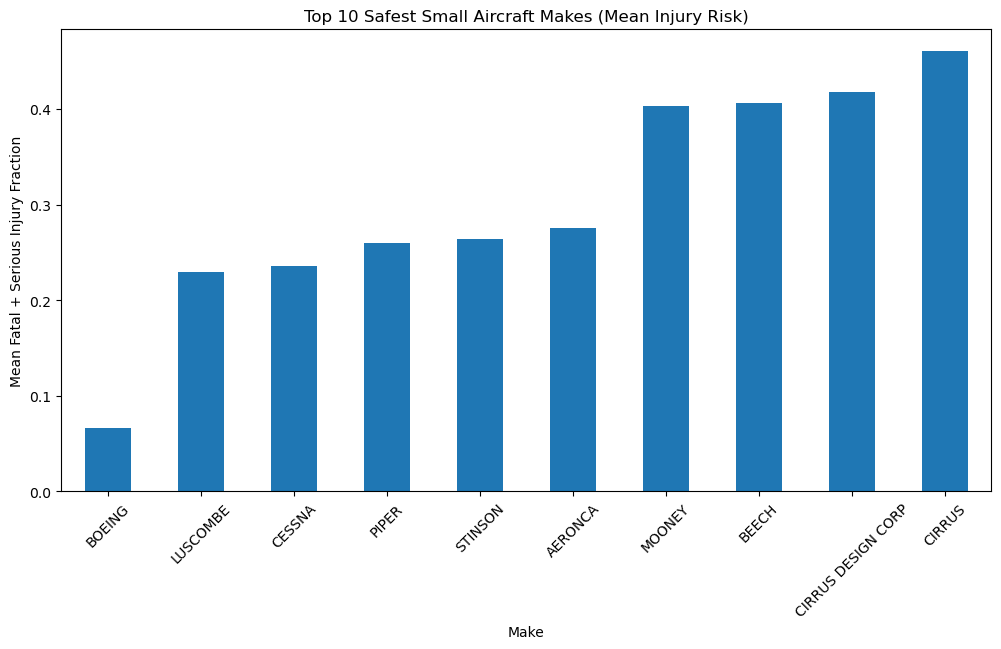

In [38]:
#plot mean injury risk for small planes

plt.figure(figsize=(12,6))

small_top10.plot(kind="bar")

plt.title("Top 10 Safest Small Aircraft Makes (Mean Injury Risk)")
plt.ylabel("Mean Fatal + Serious Injury Fraction")
plt.xticks(rotation=45)
plt.show()

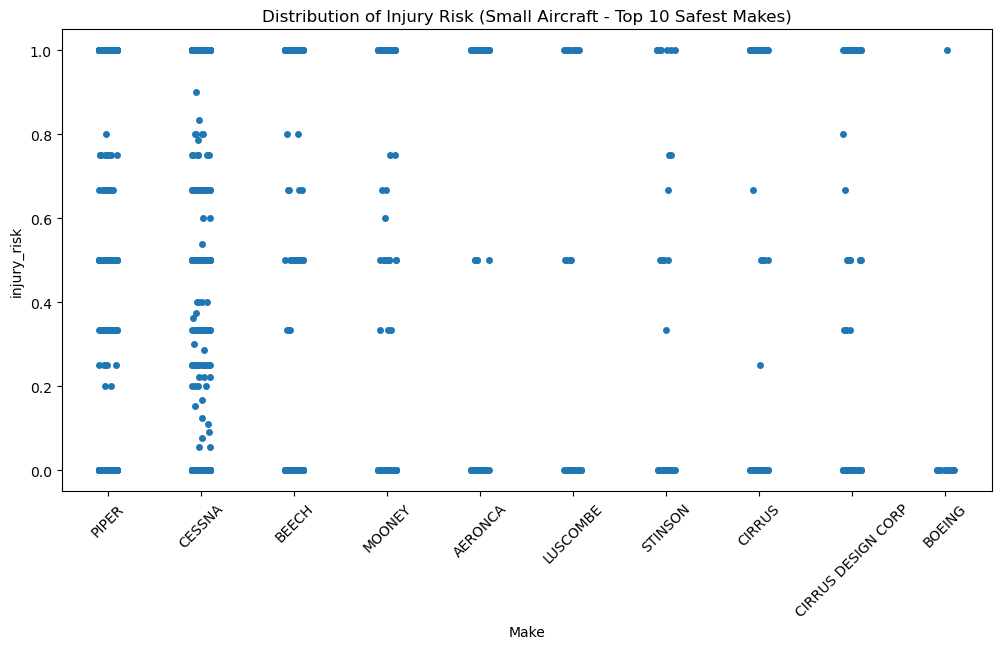

In [39]:
#distrbution plot

top_makes = small_top10.index
plot_small = small_df[small_df["Make"].isin(top_makes)]

plt.figure(figsize=(12,6))

sns.stripplot(
    data=plot_small,
    x="Make",
    y="injury_risk",
    jitter=True
)

plt.title("Distribution of Injury Risk (Small Aircraft - Top 10 Safest Makes)")
plt.xticks(rotation=45)
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Discussion on small aircraft

- Small aircraft show greater variability in both fatal and serious injury fractions across manufacturers.

- While some makes such as those with consistently low mean injury rates demonstrate strong safety performance, others show noticeable spikes in individual incidents. This suggests that small aircraft safety is more sensitive to operational conditions and design differences, leading to less consistent outcomes overal

### Discussion on large aircraft

- Large aircraft generally exhibit lower and more stable fatal and serious injury fractions compared to small aircraft.
 
- The distribution of injury risk is more tightly clustered, indicating that accidents involving large aircraft tend to have more predictable and controlled safety outcomes. Even when incidents occur, the severity is typically less variable across manufacturers


### Overal discussion

- Comparing both categories, large aircraft are generally safer and more consistent in terms of passenger injury outcomes, while small aircraft show higher variability and occasional high-risk events depending on the manufacturer.
 
- This highlights the importance of selecting aircraft type and manufacturer carefully based on operational safety requirements

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [40]:
# weather condition and safety

weather_stats = df.groupby("Weather.Condition")[[
    "Fatal_Injury_Rate",
    "Serious_Injury_Rate",
    "Is_Destroyed"
]].mean()

weather_stats

,Fatal_Injury_Rate,Serious_Injury_Rate,Is_Destroyed
Weather.Condition,,,
IMC,0.617871,0.069249,0.346008
UNK,0.591414,0.042593,0.355556
UNKNOWN,0.433259,0.070193,0.276392
VMC,0.093481,0.121198,0.056530


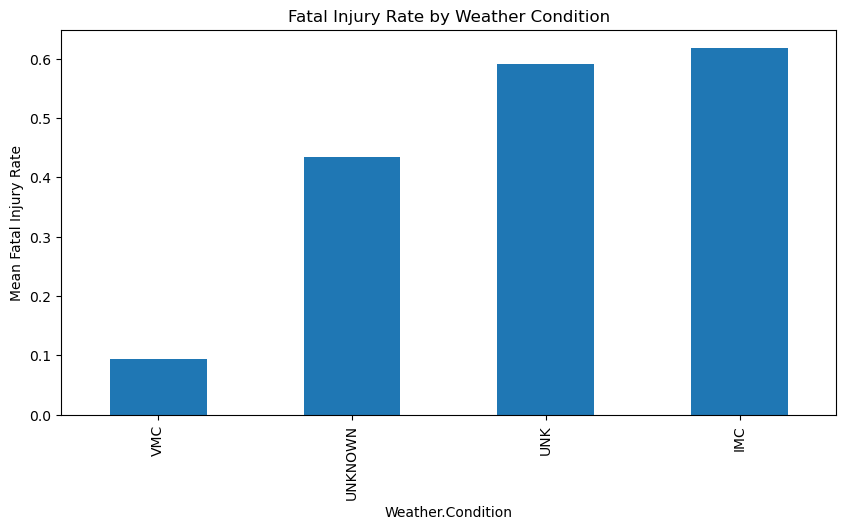

In [41]:
#plot

weather_stats["Fatal_Injury_Rate"].sort_values().plot(kind="bar", figsize=(10,5))
plt.title("Fatal Injury Rate by Weather Condition")
plt.ylabel("Mean Fatal Injury Rate")
plt.show()

### Observations

- Instrument meteorological conditions (IMC / poor weather) show higher fatal and serious injury rates compared to visual conditions.

- Accidents in poor weather are more severe due to reduced visibility and delayed pilot response.

- Clear weather conditions generally show lower injury severity and lower destruction rates, indicating better controllability.


In [42]:
#phase of light and safety

phase_stats = df.groupby("Broad.phase.of.flight")[[
    "Fatal_Injury_Rate",
    "Serious_Injury_Rate",
    "Is_Destroyed"
]].mean()

phase_stats

,Fatal_Injury_Rate,Serious_Injury_Rate,Is_Destroyed
Broad.phase.of.flight,,,
Approach,0.100000,0.102083,0.087500
Climb,0.250000,0.250000,0.307692
Cruise,0.153290,0.027508,0.116505
Descent,0.075000,0.025000,0.050000
Go-Around,0.020833,0.025000,0.041667
Landing,0.000000,0.006796,0.009709
Maneuvering,0.364865,0.067568,0.378378
Other,0.000000,0.000000,0.000000
Standing,0.000000,0.100000,0.000000


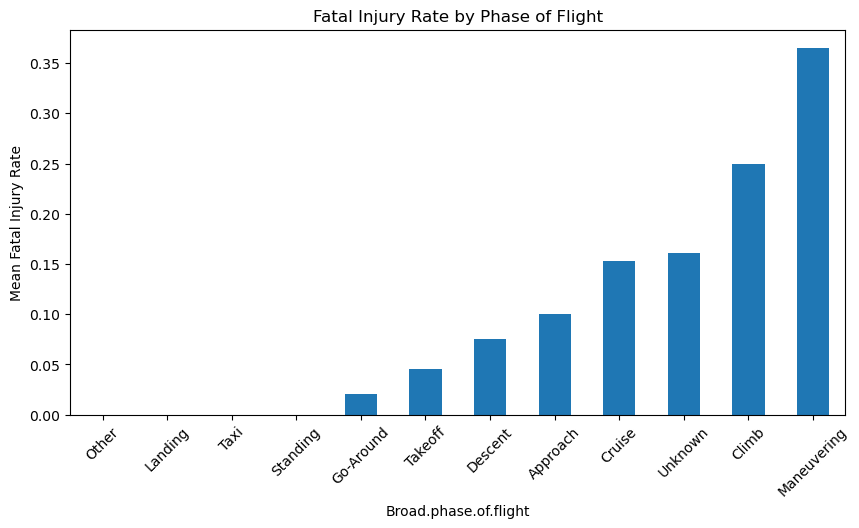

In [43]:
#plot

phase_stats["Fatal_Injury_Rate"].sort_values().plot(kind="bar", figsize=(10,5))
plt.title("Fatal Injury Rate by Phase of Flight")
plt.ylabel("Mean Fatal Injury Rate")
plt.xticks(rotation=45)
plt.show()

### observations

- The takeoff and landing phases show the highest fatal and serious injury rates.

- These phases are critical because aircraft operate at low altitude and low margin for error.

- Cruise phase shows the lowest injury and destruction rates, indicating it is the safest part of flight.
